# 01 · Schema Overview

**Week 1 Goal**: load every raw dataset, print shape / dtypes / null counts / sample rows, and capture findings into `docs/data_dictionary.md`.

Do **not** commit notebook outputs (handled by `nbstripout` in pre-commit, or strip manually before commit).

In [2]:
from pathlib import Path
import pandas as pd

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# Resolve repo root so this notebook works regardless of cwd.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'DataSet').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / 'DataSet'
assert DATA_DIR.exists(), f'DataSet folder not found from {Path.cwd()}'
print('Repo root:', REPO_ROOT)
print('Data dir :', DATA_DIR)
sorted(p.name for p in DATA_DIR.iterdir() if p.is_file())

Repo root: d:\Projects\northeastern_visualization
Data dir : d:\Projects\northeastern_visualization\DataSet


['ReadMe.md',
 'UnmatchedFaculty.csv',
 'faculty-list-2025.xlsx',
 'grants-with-abstract.xlsx',
 'grants-with-coPI.xlsx',
 'ri_matches_grants_2026.xlsx']

In [3]:
FILES = {
    'faculty':       'faculty-list-2025.xlsx',
    'grants_abs':    'grants-with-abstract.xlsx',
    'grants_copi':   'grants-with-coPI.xlsx',
    'ri_matches':    'ri_matches_grants_2026.xlsx',
}

def load_all_sheets(path: Path) -> dict[str, pd.DataFrame]:
    """Load every sheet from an xlsx into a dict[sheet_name -> DataFrame]."""
    xl = pd.ExcelFile(path)
    return {name: xl.parse(name) for name in xl.sheet_names}

raw: dict[str, dict[str, pd.DataFrame]] = {
    key: load_all_sheets(DATA_DIR / fname) for key, fname in FILES.items()
}

# Summary of sheets per file
for key, sheets in raw.items():
    print(f'{key:12s} → {FILES[key]}')
    for sheet_name, df in sheets.items():
        print(f'    sheet={sheet_name!r:35s} shape={df.shape}')
    print()

faculty      → faculty-list-2025.xlsx
    sheet='Sheet1'                            shape=(2232, 9)

grants_abs   → grants-with-abstract.xlsx
    sheet='Grants with abstract (2).csv'      shape=(8075, 25)

grants_copi  → grants-with-coPI.xlsx
    sheet='Grants with co PI indicator (1)'   shape=(3136, 22)

ri_matches   → ri_matches_grants_2026.xlsx
    sheet='ri_matches_grants_2026-2-1_3-50'   shape=(3146, 22)



## Per-dataset profile

For each dataset we print:
1. Shape
2. Column → dtype
3. Null count per column
4. First 5 rows
5. `describe(include='all')` summary

If a file has multiple sheets we profile only the first; revisit in Week 2 if other sheets matter.

In [4]:
def profile(df: pd.DataFrame, label: str) -> None:
    print('=' * 80)
    print(f'{label}  —  shape={df.shape}')
    print('=' * 80)
    print('\n--- dtypes ---')
    print(df.dtypes.to_string())
    print('\n--- null counts (non-zero only) ---')
    nulls = df.isna().sum()
    print(nulls[nulls > 0].sort_values(ascending=False).to_string() or '(none)')
    print('\n--- head(5) ---')
    display(df.head(5))
    print('\n--- describe(include="all") ---')
    display(df.describe(include='all').T)

def first_sheet(sheets: dict[str, pd.DataFrame]) -> pd.DataFrame:
    return next(iter(sheets.values()))

## Top 10 faculty earners by total grant dollars

Source: `ri_matches_grants_2026` (canonical structured grants table). Each grant is split across faculty rows; to avoid double-counting a multi-PI grant, we deduplicate to one `(grantid, AAUID)` row and then sum `totaldollars` per faculty member. Co-PIs share full credit for the grant they were attached to.


In [5]:
ri = first_sheet(raw['ri_matches'])

top10 = (
    ri.drop_duplicates(subset=['grantid', 'AAUID'])
      .groupby(['AAUID', 'personname'], as_index=False)
      .agg(
          total_dollars=('totaldollars', 'sum'),
          n_grants=('grantid', 'nunique'),
          n_as_copi=('iscopi', 'sum'),
          first_year=('startdateyear', 'min'),
          last_year=('startdateyear', 'max'),
      )
      .sort_values('total_dollars', ascending=False)
      .head(10)
      .reset_index(drop=True)
)
top10['total_dollars'] = top10['total_dollars'].map(lambda v: f'${v:,.0f}')
top10


,AAUID,personname,total_dollars,n_grants,n_as_copi,first_year,last_year
0,743186,"MELODIA, TOMMASO","$91,387,201",40,13,2010,2025
1,2461,"ALSHAWABKEH, AKRAM N","$87,619,945",19,5,2001,2020
2,72526,"MAKRIYANNIS, ALEXANDROS","$61,984,392",25,2,2004,2022
3,512705,"LEVINE, HERBERT","$47,122,908",36,7,2001,2025
4,270037,"LEWIS, KIM","$46,153,290",21,1,2004,2022
5,95218,"QUARANTA, VITO","$45,827,727",14,1,2004,2018
6,98196,"WINSLOW, RAI LESTER","$40,300,548",21,3,2005,2020
7,112255,"ABUR, ALI","$38,745,428",8,1,2005,2024
8,149515,"KAELI, DAVID R","$33,796,673",33,15,1995,2024
9,134929,"BRONICH, TATIANA KARPOVNA","$33,482,077",12,2,2005,2018


## Faculty Distribution

In [6]:
faculty = first_sheet(raw['faculty'])

by_college = (
    faculty.groupby('Superior_Academic_Unit', as_index=False)
           .agg(n_faculty=('Employee ID', 'nunique'))
           .sort_values('n_faculty', ascending=False)
           .reset_index(drop=True)
)
total = by_college['n_faculty'].sum()
by_college['pct_of_total'] = (by_college['n_faculty'] / total * 100).round(1).astype(str) + '%'
print(f'Total faculty: {total:,}  across {len(by_college)} colleges')
by_college


Total faculty: 2,232  across 12 colleges


,Superior_Academic_Unit,n_faculty,pct_of_total
0,College of Engineering,356,15.9%
1,College of Science,332,14.9%
2,College of Social Sciences and Humanities,304,13.6%
3,Bouvé College of Health Sciences,269,12.1%
4,D'Amore-McKim School of Business,215,9.6%
5,"College of Arts, Media and Design",210,9.4%
6,Khoury College of Computer Sciences,210,9.4%
7,Northeastern University London,126,5.6%
8,College of Professional Studies,110,4.9%
9,School of Law,58,2.6%


In [7]:
#Academic Rank
faculty = first_sheet(raw['faculty'])

by_college = (
    faculty.groupby('Academic Rank', as_index=False)
           .agg(n_faculty=('Employee ID', 'nunique'))
           .sort_values('n_faculty', ascending=False)
           .reset_index(drop=True)
)
total = by_college['n_faculty'].sum()
by_college['pct_of_total'] = (by_college['n_faculty'] / total * 100).round(1).astype(str) + '%'
print(f'Total faculty: {total:,}  across {len(by_college)} colleges')
by_college


Total faculty: 2,232  across 35 colleges


,Academic Rank,n_faculty,pct_of_total
0,Professor,433,19.4%
1,Associate Professor,268,12.0%
2,Assistant Professor,257,11.5%
3,Associate Teaching Professor,251,11.2%
4,Assistant Teaching Professor,232,10.4%
5,Teaching Professor,188,8.4%
6,Assistant Professor -UK,75,3.4%
7,Assistant Coop Coordinator,54,2.4%
8,Assistant Clinical Professor,52,2.3%
9,Associate Professor -UK,48,2.2%


In [8]:
# College Breakdown
faculty = first_sheet(raw['faculty'])

# Pivot: Academic Unit × Academic Track Type
pivot_unit = faculty.pivot_table(
    index='Superior_Academic_Unit',
    columns='Academic Track Type',
    values='Employee ID',
    aggfunc='nunique',
    fill_value=0,
)
pivot_unit['TOTAL'] = pivot_unit.sum(axis=1)
pivot_unit = pivot_unit.sort_values('TOTAL', ascending=False)
pivot_unit.index.name = 'Academic Unit'
pivot_unit.columns.name = None

# Same column ordering: tenure-related first, then others, then TOTAL
cols = [c for c in pivot_unit.columns if c != 'TOTAL']
tenure_cols = sorted([c for c in cols if 'tenure' in str(c).lower()])
other_cols  = sorted([c for c in cols if 'tenure' not in str(c).lower()])
pivot_unit = pivot_unit[tenure_cols + other_cols + ['TOTAL']]

print(f'{len(pivot_unit)} academic units\n')
pivot_unit


12 academic units



,Non-Tenure,Tenure Track,Research Only,Teaching Only,Teaching and Research,Teaching and Scholarship,Visiting Lecturers,TOTAL
Academic Unit,,,,,,,,
College of Engineering,149,207,0,0,0,0,0,356
College of Science,143,172,0,2,2,8,5,332
College of Social Sciences and Humanities,122,152,0,0,0,4,26,304
Bouvé College of Health Sciences,174,87,0,0,0,0,8,269
D'Amore-McKim School of Business,122,93,0,0,0,0,0,215
"College of Arts, Media and Design",100,103,0,0,0,0,7,210
Khoury College of Computer Sciences,129,80,0,0,0,0,1,210
Northeastern University London,0,0,4,8,45,69,0,126
College of Professional Studies,106,1,0,0,0,0,3,110


In [9]:
# Academic Unit Breakdown
faculty = first_sheet(raw['faculty'])

# Pivot: Academic Unit × Academic Track Type
pivot_unit = faculty.pivot_table(
    index='Academic Unit',
    columns='Academic Track Type',
    values='Employee ID',
    aggfunc='nunique',
    fill_value=0,
)
pivot_unit['TOTAL'] = pivot_unit.sum(axis=1)
pivot_unit = pivot_unit.sort_values('TOTAL', ascending=False)
pivot_unit.index.name = 'Academic Unit'
pivot_unit.columns.name = None

# Same column ordering: tenure-related first, then others, then TOTAL
cols = [c for c in pivot_unit.columns if c != 'TOTAL']
tenure_cols = sorted([c for c in cols if 'tenure' in str(c).lower()])
other_cols  = sorted([c for c in cols if 'tenure' not in str(c).lower()])
pivot_unit = pivot_unit[tenure_cols + other_cols + ['TOTAL']]

print(f'{len(pivot_unit)} academic units\n')
with pd.option_context('display.max_rows', None):
    display(pivot_unit)


80 academic units



,Non-Tenure,Tenure Track,Research Only,Teaching Only,Teaching and Research,Teaching and Scholarship,Visiting Lecturers,TOTAL
Academic Unit,,,,,,,,
Khoury College of Computer Sciences,129,80,0,0,0,0,1,210
College of Professional Studies,106,1,0,0,0,0,3,110
Electrical and Computer Engineering,23,75,0,0,0,0,0,98
College of Engineering,82,0,0,0,0,0,0,82
Mechanical and Industrial Engineering,25,56,0,0,0,0,0,81
Art and Design,40,38,0,0,0,0,1,79
Physics,17,49,0,0,0,0,0,66
English,33,20,0,0,0,0,12,65
School of Law,22,33,0,0,0,0,3,58


Matched faculty  : 542 of 2,232 (24.3% of roster)
Total grant-rows : 2,964

College-level grant summary:


,n_faculty_total,n_with_grants,pct_with_grants,n_grants,total_dollars,avg_grants_per_person,avg_dollars_per_person,total_copi
Superior_Academic_Unit,,,,,,,,
College of Engineering,356,172,48.3,1148,955332019,6.674419,5554256.0,294
College of Science,332,142,42.8,868,683530322,6.112676,4813594.0,185
Khoury College of Computer Sciences,210,68,32.4,420,329848931,6.176471,4850720.0,109
Bouvé College of Health Sciences,269,66,24.5,292,391758688,4.424242,5935738.0,38
College of Social Sciences and Humanities,304,50,16.4,142,91106859,2.840000,1822137.0,45
"College of Arts, Media and Design",210,24,11.4,61,40331454,2.541667,1680477.0,29
School of Law,58,7,12.1,12,9317837,1.714286,1331120.0,4
D'Amore-McKim School of Business,215,9,4.2,11,4600125,1.222222,511125.0,3
Northeastern University,2,1,50.0,6,1190045,6.000000,1190045.0,2


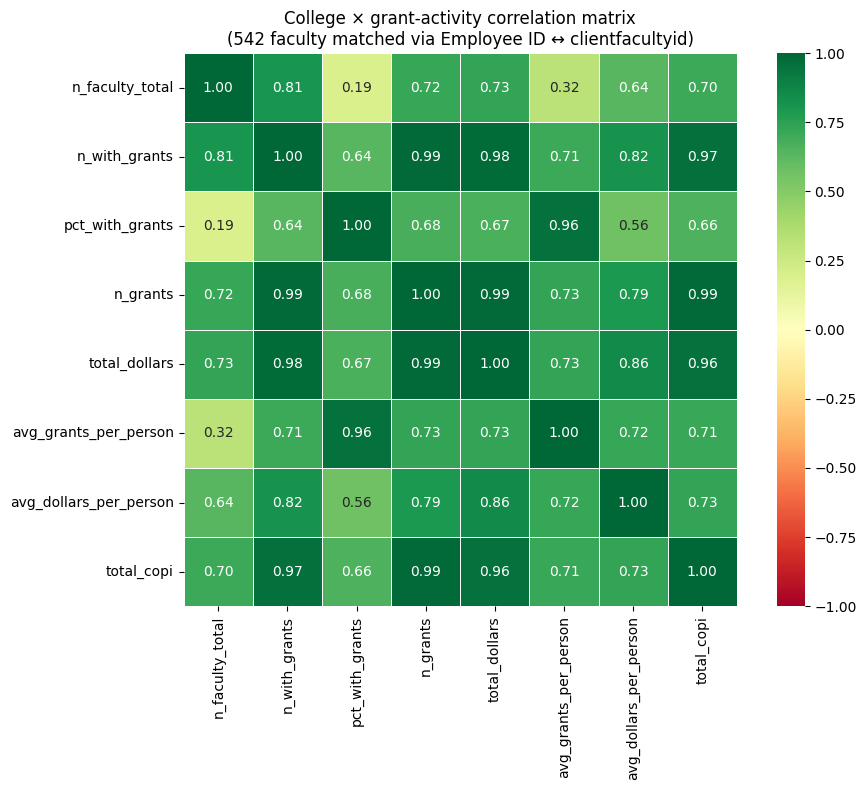

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

faculty = first_sheet(raw['faculty'])
ri      = first_sheet(raw['ri_matches'])

# ── Join: Employee ID ↔ clientfacultyid ──────────────────────────────────────
ri_dedup = ri.drop_duplicates(subset=['grantid', 'AAUID'])

per_person = (
    ri_dedup.groupby('clientfacultyid', as_index=False)
            .agg(
                n_grants           = ('grantid',      'nunique'),
                total_dollars      = ('totaldollars',  'sum'),
                n_copi             = ('iscopi',        'sum'),
                n_agencies         = ('agencyname',   'nunique'),
                year_span          = ('startdateyear', lambda x: int(x.max() - x.min() + 1) if x.notna().any() else 0),
            )
)

merged = faculty.merge(
    per_person,
    left_on='Employee ID',
    right_on='clientfacultyid',
    how='inner',
)

n_matched  = merged['Employee ID'].nunique()
n_total    = faculty['Employee ID'].nunique()
n_grants   = merged['n_grants'].sum()
print(f"Matched faculty  : {n_matched:,} of {n_total:,} ({n_matched/n_total*100:.1f}% of roster)")
print(f"Total grant-rows : {int(n_grants):,}\n")

# ── College-level grant summary ───────────────────────────────────────────────
faculty_counts = (
    faculty.groupby('Superior_Academic_Unit')['Employee ID']
           .nunique()
           .rename('n_faculty_total')
)

college_stats = (
    merged.groupby('Superior_Academic_Unit')
          .agg(
              n_with_grants         = ('Employee ID',   'nunique'),
              n_grants              = ('n_grants',      'sum'),
              total_dollars         = ('total_dollars', 'sum'),
              avg_grants_per_person = ('n_grants',      'mean'),
              total_copi            = ('n_copi',        'sum'),
          )
          .join(faculty_counts)
)
college_stats['pct_with_grants'] = (
    college_stats['n_with_grants'] / college_stats['n_faculty_total'] * 100
).round(1)
college_stats['avg_dollars_per_person'] = (
    college_stats['total_dollars'] / college_stats['n_with_grants']
).round(0)
college_stats = college_stats.sort_values('n_grants', ascending=False)

print("College-level grant summary:")
display(college_stats[[
    'n_faculty_total', 'n_with_grants', 'pct_with_grants',
    'n_grants', 'total_dollars', 'avg_grants_per_person',
    'avg_dollars_per_person', 'total_copi',
]])

# ── Correlation matrix ────────────────────────────────────────────────────────
corr_cols = [
    'n_faculty_total', 'n_with_grants', 'pct_with_grants',
    'n_grants', 'total_dollars', 'avg_grants_per_person',
    'avg_dollars_per_person', 'total_copi',
]
corr = college_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True, ax=ax,
)
ax.set_title(
    f'College × grant-activity correlation matrix\n'
    f'({n_matched:,} faculty matched via Employee ID ↔ clientfacultyid)',
    fontsize=12,
)
plt.tight_layout()
plt.show()


Total PI ↔ co-PI pairs across all grants: 437
Unique grants with ≥1 co-PI            : 291

After manual mapping:
  PI missing college   : 0 of 159 unique PIs
  co-PI missing college: 0 of 212 unique co-PIs

Top 20 PI ↔ co-PI collaboration pairs (with grant details):


,pi_name,pi_college,copi_name,copi_college,n_grants,grant_titles (unique grants seperated by |),agencies
0,"ONDRECHEN, MARY JO",College of Science,"BEUNING, PENNY J",College of Science,7,Are Enzyme Active Sites Built in Multiple Layers? | Chem...,National Science Foundation
1,"WOOD, DARIEN",College of Science,"BARBERIS, EMANUELA",College of Science,6,Experimental High Energy Particle Physics | Experimental...,National Science Foundation
2,"ZEID, IBRAHIM",College of Engineering,"DUGGAN, CLAIRE",College of Engineering,5,BPE-Track 2: Modernizing Education: Using AI to Improve ...,National Science Foundation
3,"NATH, PRAN",College of Science,"TAYLOR, TOMASZ R",College of Science,5,Research in Elementary Particle Theory | Research in Ele...,National Science Foundation
4,"SZNAIER, MARIO",College of Engineering,"CAMPS, OCTAVIA",College of Engineering,5,CPS:Medium: Safe Learning-Enabled Cyberphysical Systems ...,National Science Foundation
...,...,...,...,...,...,...,...
341,"KAMARTHI, SAGAR V",College of Engineering,"ISAACS, JACKIE A",College of Engineering,1,Developing Integrative Manufacturing and Production Engi...,National Science Foundation
342,"KAELI, DAVID R",College of Engineering,"WANG, YANZHI",College of Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation
343,"KAELI, DAVID R",College of Engineering,"TIWARI, DEVESH",College of Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation
344,"KAELI, DAVID R",College of Engineering,"LIN, XUE",College of Engineering,1,MRI: Acquisition of a Heterogeneous Multi-GPU Cluster to...,National Science Foundation



Pairs with both sides matched to a college: 437 of 437 (100.0%)



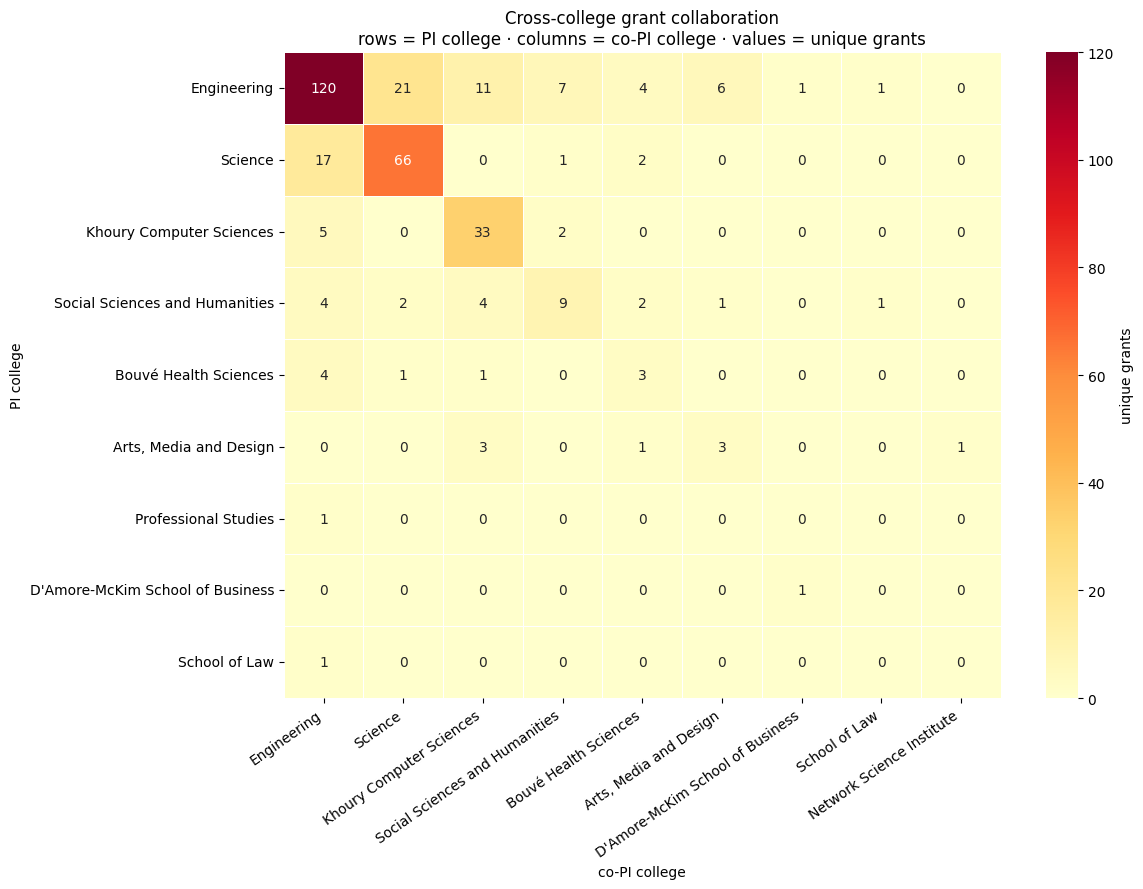

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

faculty = first_sheet(raw['faculty'])
ri      = first_sheet(raw['ri_matches'])

ri_dedup = ri.drop_duplicates(subset=['grantid', 'AAUID'])

# ── 1. Build PI ↔ co-PI pairs per grant ──────────────────────────────────────
pi_rows   = ri_dedup[ri_dedup['iscopi'] == 0][['grantid', 'clientfacultyid', 'personname']].rename(
    columns={'clientfacultyid': 'pi_id', 'personname': 'pi_name'})
copi_rows = ri_dedup[ri_dedup['iscopi'] == 1][['grantid', 'clientfacultyid', 'personname']].rename(
    columns={'clientfacultyid': 'copi_id', 'personname': 'copi_name'})

pairs = pi_rows.merge(copi_rows, on='grantid')
print(f"Total PI ↔ co-PI pairs across all grants: {len(pairs):,}")
print(f"Unique grants with ≥1 co-PI            : {pairs['grantid'].nunique():,}\n")

# ── 1b. Add grant details (title and funding source) ─────────────────────────
grant_details = ri_dedup[['grantid', 'grantname', 'agencyname']].drop_duplicates(subset=['grantid'])
pairs = pairs.merge(grant_details, on='grantid', how='left')

# ── 2. Enrich each person with college via Employee ID ↔ clientfacultyid ──────
id_to_college = (
    faculty.dropna(subset=['Employee ID'])
           .set_index('Employee ID')['Superior_Academic_Unit']
           .to_dict()
)

pairs['pi_college']   = pairs['pi_id'].map(id_to_college)
pairs['copi_college'] = pairs['copi_id'].map(id_to_college)

# ── 2b. Load manual mapping for unmatched faculty and fill in missing colleges ──
sheet1 = pd.read_csv(REPO_ROOT / 'DataSet/UnmatchedFaculty.csv', header=None, 
                     names=['idx', 'id', 'name', 'college_raw', 'department_raw'])

# Map college names to match faculty roster's Superior_Academic_Unit
college_mapping = {
    'Engineering': 'College of Engineering',
    'College of science': 'College of Science',
    'Khoury': 'Khoury College of Computer Sciences',
    'Math?': 'College of Science',
    'Network science institute': 'Network Science Institute',
}

sheet1['superior_academic_unit'] = sheet1['college_raw'].map(college_mapping)

# Create lookup dictionary from manual mapping
manual_id_to_college = sheet1.set_index('id')['superior_academic_unit'].to_dict()

# Fill in missing colleges using manual mapping
pairs['pi_college'] = pairs['pi_college'].fillna(pairs['pi_id'].map(manual_id_to_college))
pairs['copi_college'] = pairs['copi_college'].fillna(pairs['copi_id'].map(manual_id_to_college))

print(f"After manual mapping:")
print(f"  PI missing college   : {pairs['pi_college'].isna().sum()} of {len(pairs.drop_duplicates('pi_id'))} unique PIs")
print(f"  co-PI missing college: {pairs['copi_college'].isna().sum()} of {len(pairs.drop_duplicates('copi_id'))} unique co-PIs\n")

# ── 3. All collaboration pairs (with colleges, grant titles, and agencies) ────
all_pairs = (
    pairs.groupby(['pi_name', 'pi_college', 'copi_name', 'copi_college'], as_index=False, dropna=False)
         .agg(
             n_grants=('grantid', 'nunique'),
             **{'grant_titles (unique grants seperated by |)': ('grantname', lambda x: ' | '.join(sorted(set(x.dropna()))[:5]) )},  # Top 5 unique titles
             agencies=('agencyname', lambda x: ', '.join(sorted(set(x.dropna()))))
         )
         .sort_values('n_grants', ascending=False)
         .reset_index(drop=True)
)
all_pairs['pi_college']   = all_pairs['pi_college'].fillna('(still unmatched)')
all_pairs['copi_college'] = all_pairs['copi_college'].fillna('(still unmatched)')
print("Top 20 PI ↔ co-PI collaboration pairs (with grant details):")
with pd.option_context('display.max_rows', 20, 'display.max_colwidth', 60):
    display(all_pairs[['pi_name', 'pi_college', 'copi_name', 'copi_college', 'n_grants', 'grant_titles (unique grants seperated by |)', 'agencies']])
    
all_pairs.to_csv(REPO_ROOT / 'outputs' / 'collab_pairs.csv', index=False)

# ── 4. College × college collaboration matrix ─────────────────────────────────
matched = pairs.dropna(subset=['pi_college', 'copi_college'])
n_pairs_matched = len(matched)
n_pairs_total   = len(pairs)
print(f"\nPairs with both sides matched to a college: {n_pairs_matched:,} of {n_pairs_total:,} "
      f"({n_pairs_matched/n_pairs_total*100:.1f}%)\n")

collab_matrix = (
    matched.groupby(['pi_college', 'copi_college'])['grantid']
           .nunique()
           .unstack(fill_value=0)
)

row_order = collab_matrix.sum(axis=1).sort_values(ascending=False).index
col_order = collab_matrix.sum(axis=0).sort_values(ascending=False).index
collab_matrix = collab_matrix.loc[row_order, col_order]

short = lambda s: s.replace('College of ', '').replace('Northeastern University ', 'NU ')
collab_matrix.index   = [short(c) for c in collab_matrix.index]
collab_matrix.columns = [short(c) for c in collab_matrix.columns]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    collab_matrix, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.4, ax=ax, cbar_kws={'label': 'unique grants'}
)
ax.set_title(
    'Cross-college grant collaboration\n'
    'rows = PI college · columns = co-PI college · values = unique grants',
    fontsize=12,
)
ax.set_xlabel('co-PI college')
ax.set_ylabel('PI college')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Summary: Unmatched individuals (still missing after manual mapping)
# Note: The 'pairs' dataframe was created in the cell above with colleges filled in via manual mapping

# Unique PIs still missing college after manual mapping
unmatched_pis = pairs[pairs['pi_college'].isna()][['pi_id', 'pi_name']].drop_duplicates()
n_unmatched_pi = len(unmatched_pis)

# Unique co-PIs still missing college after manual mapping
unmatched_copis = pairs[pairs['copi_college'].isna()][['copi_id', 'copi_name']].drop_duplicates()
n_unmatched_copi = len(unmatched_copis)

# Total unique faculty in pairs
total_unique_pis = pairs[['pi_id', 'pi_name']].drop_duplicates()
total_unique_copis = pairs[['copi_id', 'copi_name']].drop_duplicates()

print(f"Still unmatched after manual mapping:")
print(f"  PIs   : {n_unmatched_pi:,} of {len(total_unique_pis):,} "
      f"({n_unmatched_pi/len(total_unique_pis)*100:.1f}%)")
print(f"  co-PIs: {n_unmatched_copi:,} of {len(total_unique_copis):,} "
      f"({n_unmatched_copi/len(total_unique_copis)*100:.1f}%)")

if n_unmatched_pi > 0 or n_unmatched_copi > 0:
    # Combined unique individuals still unmatched
    all_still_unmatched = pd.concat([
        unmatched_pis.rename(columns={'pi_id': 'id', 'pi_name': 'name'}),
        unmatched_copis.rename(columns={'copi_id': 'id', 'copi_name': 'name'})
    ]).drop_duplicates(subset=['id']).sort_values('name').reset_index(drop=True)
    
    print(f"\nIndividuals still missing college mapping: {len(all_still_unmatched):,}")
    print("\nList of still-unmatched individuals:")
    with pd.option_context('display.max_rows', None):
        display(all_still_unmatched)
else:
    print("\n✓ All individuals successfully mapped to colleges!")

Still unmatched after manual mapping:
  PIs   : 1 of 159 (0.6%)
  co-PIs: 0 of 212 (0.0%)

Individuals still missing college mapping: 1

List of still-unmatched individuals:


,id,name
0,1061549,"KNUDSEN, BEN ERIC"


## Cross-college collaboration — chord & Sankey

Two alternative views of the same college × college collaboration matrix:

- **Chord diagram** — emphasizes the *symmetric* nature of a PI ↔ co-PI relationship. Each arc connects two colleges; the thicker the ribbon, the more grants they share. Best for spotting which college-pairs collaborate heavily and which are isolated.
- **Bipartite Sankey** — keeps PI college on the left and co-PI college on the right, treating them as distinct roles. Best for showing *directional flow* — which colleges tend to lead vs. support, and where multi-college grants concentrate.


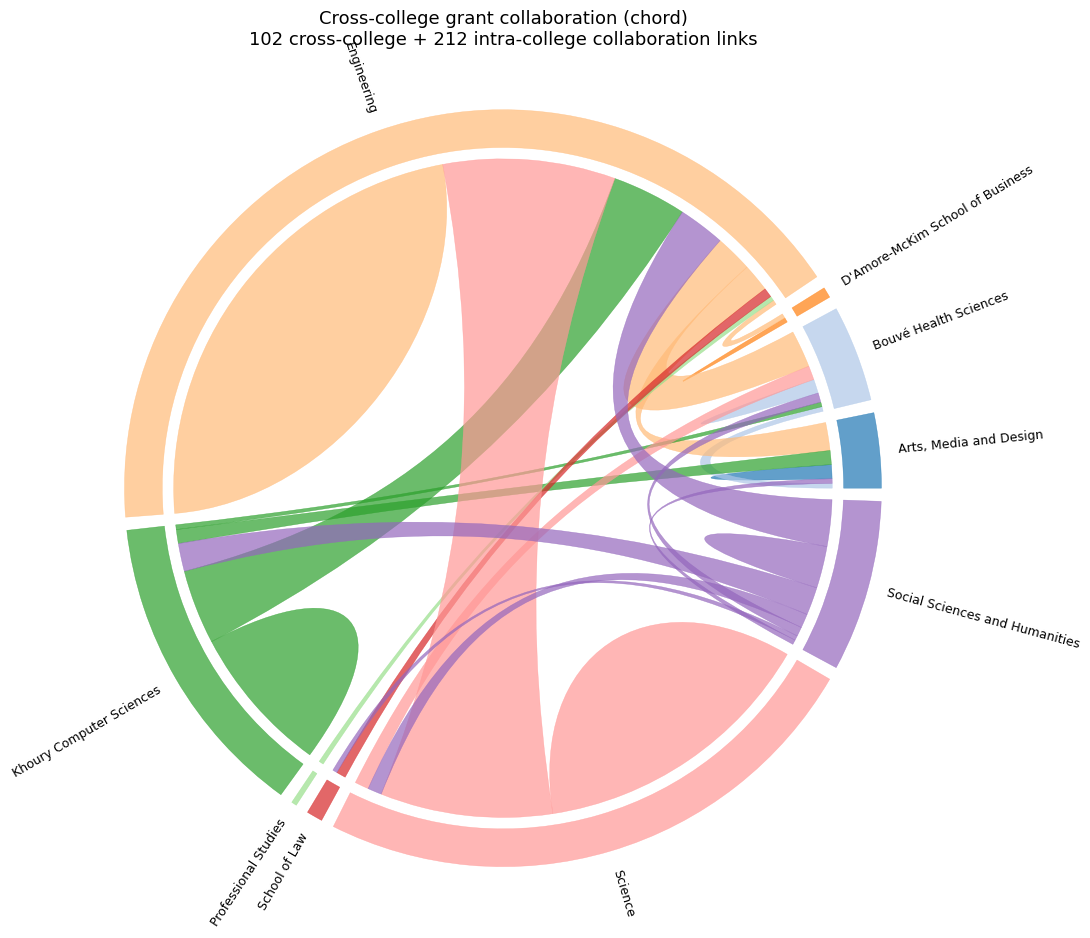

In [ ]:
# Chord diagram — symmetric PI ↔ co-PI collaboration between colleges
import numpy as np
import matplotlib.pyplot as plt
from mpl_chord_diagram import chord_diagram

# Reuse `collab_matrix` (rows=PI college, cols=co-PI college, short names).
# Align rows & columns, fill NaN, then symmetrize: sym[i,j] = collab[i,j] + collab[j,i].
all_colleges = sorted(set(collab_matrix.index) | set(collab_matrix.columns))
cm = collab_matrix.reindex(index=all_colleges, columns=all_colleges).fillna(0)
sym = cm + cm.T
# Diagonal was double-counted — restore it
for c in all_colleges:
    sym.loc[c, c] = cm.loc[c, c]

# Drop colleges with zero total activity (nothing to draw)
keep = sym.sum(axis=1) > 0
sym = sym.loc[keep, keep]
colleges = sym.index.tolist()
mat = sym.values.astype(float)

# Color palette — one color per college
cmap = plt.get_cmap('tab20')
colors = [cmap(i % 20) for i in range(len(colleges))]

fig, ax = plt.subplots(figsize=(11, 11))
chord_diagram(
    mat,
    names=colleges,
    colors=colors,
    alpha=0.7,
    pad=2.0,
    gap=0.03,
    sort='size',
    rotate_names=True,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    'Cross-college grant collaboration (chord)\n'
    f'{int(mat.sum() - np.trace(mat)) // 2} cross-college + '
    f'{int(np.trace(mat))} intra-college collaboration links',
    fontsize=13, pad=20,
)
plt.tight_layout()
plt.show()


In [ ]:
# Bipartite Sankey — PI college (left) → co-PI college (right)
import plotly.graph_objects as go

# Long-form flow table from the matrix we already built (using short labels)
flows = (
    collab_matrix.stack()
                 .reset_index()
                 .rename(columns={'pi_college': 'src', 'copi_college': 'dst', 0: 'n_grants'})
)
flows.columns = ['src', 'dst', 'n_grants']
flows = flows[flows['n_grants'] > 0]

# Distinct node IDs for left (PI) and right (co-PI) sides
src_labels = sorted(flows['src'].unique())
dst_labels = sorted(flows['dst'].unique())
left_nodes  = [f'{c}  (PI)'    for c in src_labels]
right_nodes = [f'(co-PI)  {c}' for c in dst_labels]
all_nodes   = left_nodes + right_nodes
node_idx = {n: i for i, n in enumerate(all_nodes)}

# Consistent color per college (regardless of side)
import matplotlib.colors as mc
palette = plt.get_cmap('tab20')
college_colors = {c: mc.to_hex(palette(i % 20)) for i, c in enumerate(sorted(set(src_labels + dst_labels)))}
node_colors = (
    [college_colors[c] for c in src_labels] +
    [college_colors[c] for c in dst_labels]
)

# Link colors: use the PI-side color, semi-transparent
def rgba(hex_color, alpha=0.45):
    r, g, b = [int(hex_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4)]
    return f'rgba({r},{g},{b},{alpha})'

sources = [node_idx[f'{r.src}  (PI)']    for r in flows.itertuples()]
targets = [node_idx[f'(co-PI)  {r.dst}'] for r in flows.itertuples()]
values  = flows['n_grants'].tolist()
link_colors = [rgba(college_colors[r.src]) for r in flows.itertuples()]

fig = go.Figure(go.Sankey(
    arrangement='snap',
    node=dict(
        label=all_nodes,
        color=node_colors,
        pad=14, thickness=18,
        line=dict(color='rgba(0,0,0,0.4)', width=0.5),
    ),
    link=dict(
        source=sources, target=targets,
        value=values, color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>%{value} grants<extra></extra>',
    ),
))
fig.update_layout(
    title=dict(
        text='PI college → co-PI college  (grant collaboration flow)',
        x=0.5, xanchor='center',
    ),
    font=dict(size=11),
    height=650, margin=dict(l=10, r=10, t=70, b=10),
)
fig.show()


## Action items → `docs/data_dictionary.md`

### Questions 

1. **The grants for faculty members list all grants throughout their career** We cannot devise which grants are from their Northeastern career since we do not know when they started at Northeastern

5. **The faculty list does not account for when they were active in Northeastern** Having active time period of faculty member in Northeastern would help evaluate the grant analysis

6. **Focus on aggregrate info research first** Gradual examination of aggregrate trends - do not want to explore research ideas. 

7. **Topic analysis** What kind of research are we doing in Northeastern?

8. **Collaboration between Faculty** Review the coPI between faculty - interdisciplinary collaboration between faculty is important - interdisciplinrity between colleges in Northeastern is very relevant

9. **Correlation Matrix todo** Researchers vs coPI vs colleges.

4. **Who is the wider audience, really?** can mean prospective students, donors, prospective faculty, accreditation visitors, or current NU researchers — each of those wants a different story. If you had to pick the *one* visitor I should design for, who is it?

5. **What is the headline story you'd want this to tell?** I can already see candidates in the data has an explosive growth post-2010 (Khoury alone has 210 faculty now), the NSF-heavy funding mix (2,123 of ~2,670 grants), the concentration of dollars in a small group of mega-PIs (Melodia 40 grants, Levine 36, Kaeli 33). Any you would want to lead with?

6. **Are there stories the data could tell that we should *not* tell?** Like funding inequality by department, by tenure status, by gender (if we ever get that data), or year-over-year declines in specific colleges are all things this dataset can show. I'd rather know now if any of those are no-go zones, vs build a chart and have to kill it in August.

7. **What's missing that you wish we had?** The faculty 2025 roster - lists all faculty but does not distinguish on their current status - is this everyone who has been party of Northeastern or only active 2025 faculty members? Is there a historical faculty roster (with hire/departure dates) I should request? Same question for demographic data — I *do not* want to guess at this; want to know if it exists and whether equity analysis is in scope - or if you would want me to gather this information via scraping their linkedin or personal website information.

8. **What kind of trend are we focusing on?** Creating a time-series chart would show the "trend" on the grants coming in to Northeastern over the years. But what counts as a "trend", and what kind of "trend" do we want to focus on.
